In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [5]:
df = pd.read_csv(r'C:\Users\Admin\Desktop\adult.data', header=None, na_values=[' ?', '? ', '?', ' ? '])

In [7]:
column_names = ['age', 'workclass', 'id_number', 'education', 'education_num', 
                'marital_status', 'occupation', 'relationship', 'race', 
                'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 
                'native_country', 'income']

In [8]:
df.columns = column_names

In [12]:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (32561, 15)

First 5 rows:


,age,workclass,id_number,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [28]:
# This section focuses on Data Quality Assessment
# This is the documentation of the comprehensive data report

def data_quality_report(df):
     report = {
        'column': [],
        'dtype': [],
        'total_values': [],
        'missing_values': [],
        'missing_percent': [],
        'unique_values': [],
        'data_type': [],
        'suspected_issues': []
    }
    
     for col in df.columns:
        report['column'].append(col)
        report['dtype'].append(df[col].dtype)
        report['total_values'].append(len(df[col]))

        missing = df[col].isnull().sum()
        report['missing_values'].append(missing)
        report['missing_percent'].append(round(missing/len(df)*100, 2))

        unique = df[col].nunique()
        report['unique_values'].append(unique)

        if df[col].dtype in ['int64', 'float64']:
            report['data_type'].append('Numerical')
        else:
            report['data_type'].append('Categorical')

        issues = []
        if missing > 0:
            issues.append('Missing values')
        
        if df[col].dtype == 'object':
            
            unique_vals = df[col].dropna().unique()
            str_vals = [str(x).strip().lower() for x in unique_vals]
            if len(set(str_vals)) < len(unique_vals):
                issues.append('Inconsistent labels')
            
            # Check for mixed data types
            type_counts = df[col].apply(lambda x: type(x).__name__).value_counts()
            if len(type_counts) > 1:
                issues.append('Mixed data types')
        
        report['suspected_issues'].append('; '.join(issues) if issues else 'None')

     return pd.DataFrame(report)

In [29]:
quality_report = data_quality_report(df)
print("DATA QUALITY ASSESSMENT REPORT")
print("=" * 80)
display(quality_report)

DATA QUALITY ASSESSMENT REPORT


,column,dtype,total_values,missing_values,missing_percent,unique_values,data_type,suspected_issues
0,age,int64,32561,0,0.00,73,Numerical,None
1,workclass,object,32561,1836,5.64,8,Categorical,Missing values; Mixed data types
2,id_number,int64,32561,0,0.00,21648,Numerical,None
3,education,object,32561,0,0.00,16,Categorical,None
4,education_num,int64,32561,0,0.00,16,Numerical,None
5,marital_status,object,32561,0,0.00,7,Categorical,None
6,occupation,object,32561,1843,5.66,14,Categorical,Missing values; Mixed data types
7,relationship,object,32561,0,0.00,6,Categorical,None
8,race,object,32561,0,0.00,5,Categorical,None
9,sex,object,32561,0,0.00,2,Categorical,None


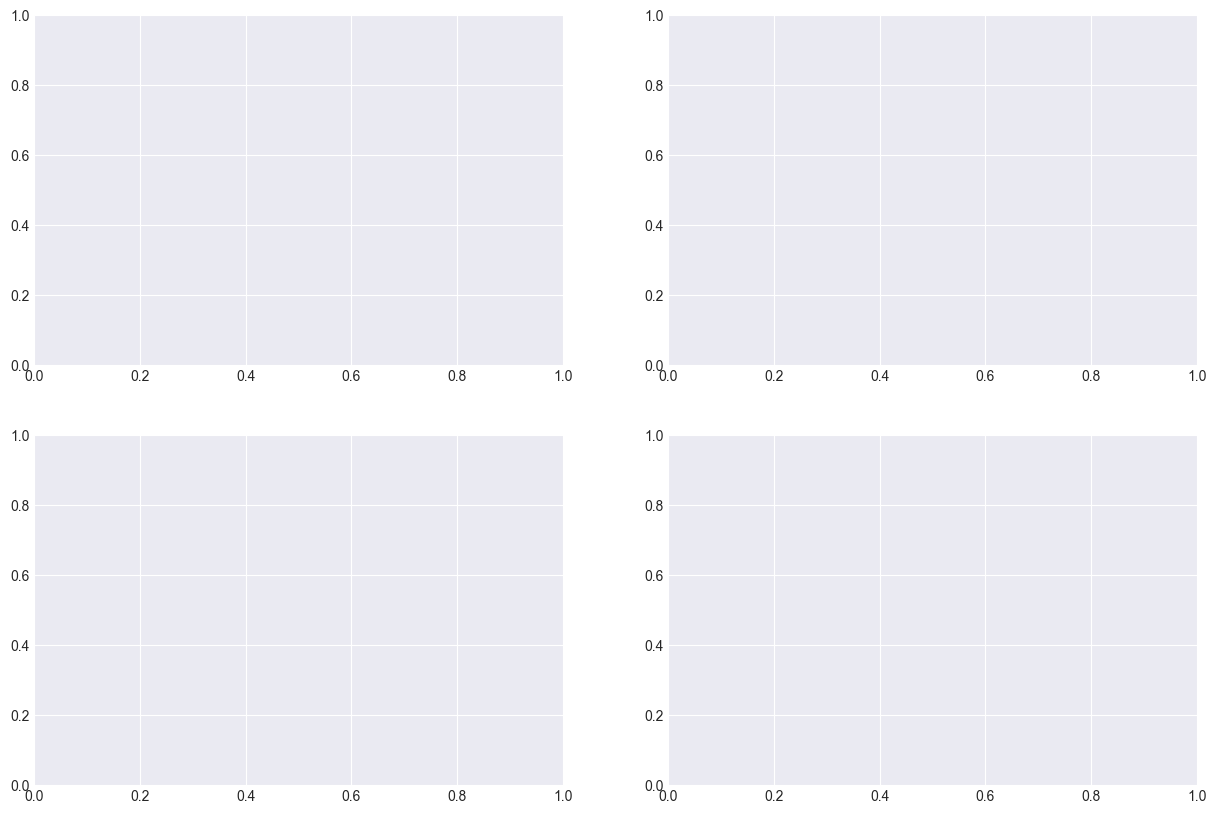

In [30]:
# This section focuses on visualizing of the missing values

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

Text(0.5, 1.0, 'Missing Values Heatmap')

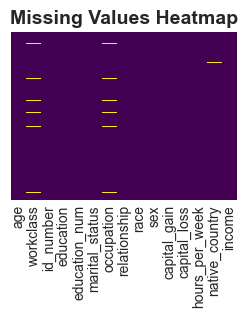

In [31]:
# 1. Heatmap on missing values

missing_data = df.isnull()
plt.subplot(2, 2, 1)
sns.heatmap(missing_data, cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap', fontsize=14, fontweight='bold')

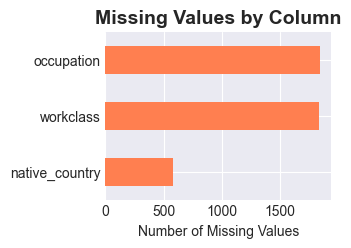

In [32]:
# 2. Missing values by columns

plt.subplot(2, 2, 2)
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
if len(missing_counts) > 0:
    missing_counts.sort_values().plot(kind='barh', color='coral')
    plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Missing Values')
else:
    plt.text(0.5, 0.5, 'No Missing Values Found', 
             ha='center', va='center', fontsize=12)
    plt.title('Missing Values by Column', fontsize=14, fontweight='bold')

Text(0, 0.5, '')

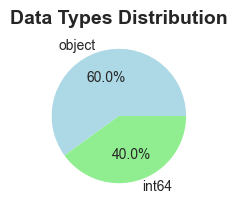

In [33]:
# 3. Distribution of data types

plt.subplot(2, 2, 3)
dtype_counts = df.dtypes.value_counts()
dtype_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'lightcoral'])
plt.title('Data Types Distribution', fontsize=14, fontweight='bold')
plt.ylabel('')

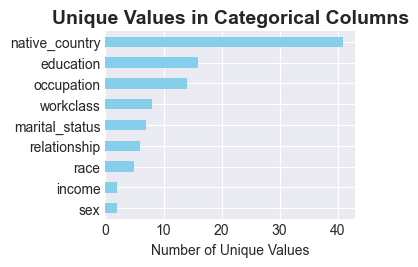

In [34]:
# 4. Unique values for categorical columns

plt.subplot(2, 2, 4)
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    unique_counts = df[cat_cols].nunique().sort_values()
    unique_counts.plot(kind='barh', color='skyblue')
    plt.title('Unique Values in Categorical Columns', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Unique Values')
else:
    plt.text(0.5, 0.5, 'No Categorical Columns', 
             ha='center', va='center', fontsize=12)
    plt.title('Unique Values in Categorical Columns', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [40]:
# This part gives a Detailed Analysis of specific issues

def analyze_categorical_inconsistencies(df, column):
    if df[column].dtype == 'object':
        print(f"\n Analysis of '{column}':")
        print("-" * 50)
        
        #unique values with their frequencies
        value_counts = df[column].value_counts(dropna=False)
        print(f"Total unique values: {len(value_counts)}")
        
        #case inconsistencies
        lower_case_counts = df[column].str.lower().value_counts()
        if len(lower_case_counts) < len(value_counts):
            print(f"Case inconsistencies found: {len(value_counts) - len(lower_case_counts)} variations")
        
        #whitespace inconsistencies
        stripped_counts = df[column].astype(str).str.strip().value_counts()
        if len(stripped_counts) < len(value_counts):
            print(f"Whitespace inconsistencies found: {len(value_counts) - len(stripped_counts)} variations")
        
        # Display top values
        print("\nTop 10 values:")
        display(value_counts.head(10))
        
        return value_counts

In [41]:
key_categorical_cols = ['workclass', 'education', 'marital_status', 'occupation', 
                        'relationship', 'race', 'sex', 'native_country', 'income']
for col in key_categorical_cols:
    if col in df.columns:
        analyze_categorical_inconsistencies(df, col)


 Analysis of 'workclass':
--------------------------------------------------
Total unique values: 9
Case inconsistencies found: 1 variations

Top 10 values:


workclass
 Private             22696
 Self-emp-not-inc     2541
 Local-gov            2093
NaN                   1836
 State-gov            1298
 Self-emp-inc         1116
 Federal-gov           960
 Without-pay            14
 Never-worked            7
Name: count, dtype: int64


 Analysis of 'education':
--------------------------------------------------
Total unique values: 16

Top 10 values:


education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
Name: count, dtype: int64


 Analysis of 'marital_status':
--------------------------------------------------
Total unique values: 7

Top 10 values:


...

sex
Male      21790
Female    10771
Name: count, dtype: int64


 Analysis of 'native_country':
--------------------------------------------------
Total unique values: 42
Case inconsistencies found: 1 variations

Top 10 values:


native_country
 United-States    29170
 Mexico             643
NaN                 583
 Philippines        198
 Germany            137
 Canada             121
 Puerto-Rico        114
 El-Salvador        106
 India              100
 Cuba                95
Name: count, dtype: int64


 Analysis of 'income':
--------------------------------------------------
Total unique values: 2

Top 10 values:


income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [42]:
# Checking for duplicates

duplicates = df.duplicated().sum()
print(f"\nDuplicate Analysis:")
print("-" * 50)
print(f"Exact duplicate rows: {duplicates}")
print(f"Percentage of duplicates: {(duplicates/len(df)*100):.2f}%")

if duplicates > 0:
    print("\nSample duplicate rows:")
    display(df[df.duplicated(keep=False)].head())


Duplicate Analysis:
--------------------------------------------------
Exact duplicate rows: 24
Percentage of duplicates: 0.07%

Sample duplicate rows:


,age,workclass,id_number,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
2303,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
3917,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
4325,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
4767,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K


In [43]:
key_attributes = ['age', 'education', 'occupation', 'hours_per_week', 'income']
if all(attr in df.columns for attr in key_attributes):
    near_duplicates = df.duplicated(subset=key_attributes, keep=False).sum()
    print(f"\nNear duplicates (based on key attributes): {near_duplicates}")


Near duplicates (based on key attributes): 19099



Numerical Columns Analysis for Outliers:
age:
  - Mean: 38.58
  - Std: 13.64
  - Outliers (IQR method): 143 (0.44%)
id_number:
  - Mean: 189778.37
  - Std: 105549.98
  - Outliers (IQR method): 992 (3.05%)
education_num:
  - Mean: 10.08
  - Std: 2.57
  - Outliers (IQR method): 1198 (3.68%)
capital_gain:
  - Mean: 1077.65
  - Std: 7385.29
  - Outliers (IQR method): 2712 (8.33%)
capital_loss:
  - Mean: 87.30
  - Std: 402.96
  - Outliers (IQR method): 1519 (4.67%)
hours_per_week:
  - Mean: 40.44
  - Std: 12.35
  - Outliers (IQR method): 9008 (27.66%)


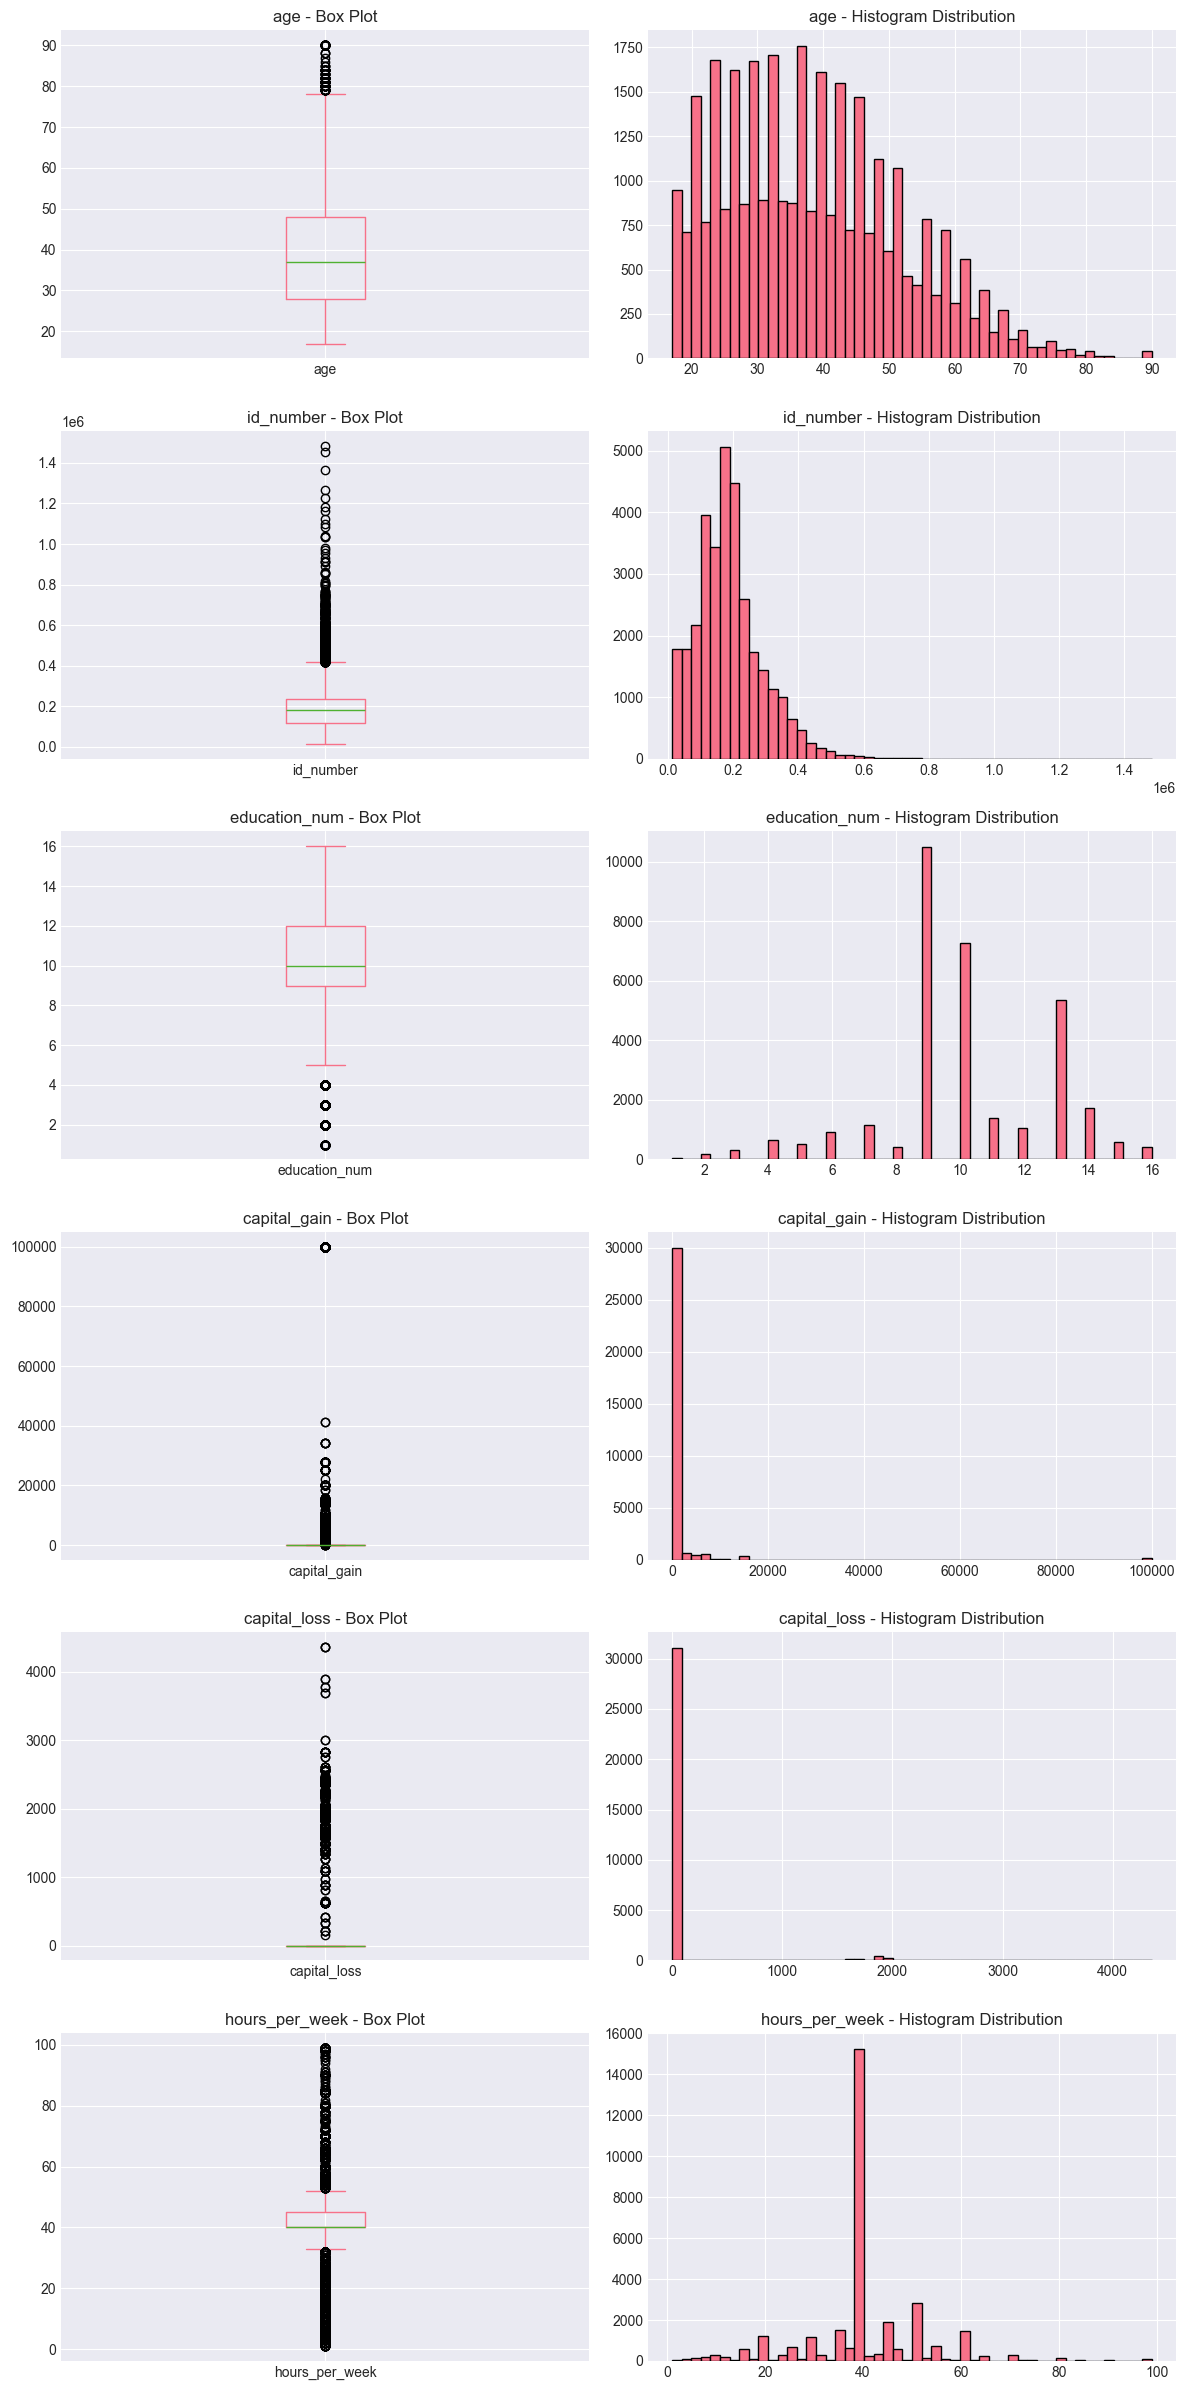

In [47]:
# This is a dive into Outliers and Abnormalities

numerical_cols = df.select_dtypes(include=[np.number]).columns
print(f"\nNumerical Columns Analysis for Outliers:")
print("=" * 60)

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(12, 4*len(numerical_cols)))

for idx, col in enumerate(numerical_cols):
    # Box plot
    plt.subplot(len(numerical_cols), 2, idx*2 + 1)
    df[col].dropna().plot(kind='box')
    plt.title(f'{col} - Box Plot')
    
    # Histogram
    plt.subplot(len(numerical_cols), 2, idx*2 + 2)
    df[col].dropna().hist(bins=50, edgecolor='black')
    plt.title(f'{col} - Histogram Distribution')
    
    # Calculate outliers using IQR method
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    
    print(f"{col}:")
    print(f"  - Mean: {df[col].mean():.2f}")
    print(f"  - Std: {df[col].std():.2f}")
    print(f"  - Outliers (IQR method): {outliers} ({(outliers/len(df)*100):.2f}%)")

plt.tight_layout()
plt.show()

In [50]:
# This section shows the Systematic Cleaning Pipeline

df_clean = df.copy()
print("STARTING DATA CLEANING PIPELINE")
print("=" * 80)

df_clean.columns = df_clean.columns.str.strip().str.lower()
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].astype(str).str.strip()
        df_clean[col] = df_clean[col].replace(['nan', 'NaN', 'Nan', 'None', 'none', ''], np.nan)

print("\nStandardizing Categorical Labels")
print("-" * 50)

standardization_rules = {
    'workclass': {
        'strategy': 'lower_case',
        'mapping': {
            'fed gov': 'federal-gov',
            'local gov': 'local-gov',
            'state gov': 'state-gov',
            'self emp': 'self-emp',
            'self-emp-inc': 'self-emp-inc',
            'self-emp-not-inc': 'self-emp-not-inc',
            'without pay': 'without-pay',
            'never worked': 'never-worked'
        }
    },
    'education': {
        'strategy': 'lower_case'
    },
    'marital_status': {
        'strategy': 'lower_case',
        'mapping': {
            'married af spouse': 'married-civ-spouse',
            'married civ spouse': 'married-civ-spouse'
        }
    },
    'income': {
        'strategy': 'binary',
        'mapping': {
            '>50k': '>50K',
            '>50k.': '>50K',
            '<=50k': '<=50K',
            '<=50k.': '<=50K'
        }
    }
}

def standardize_categorical(df, column, rules):
    if column not in df.columns:
        return df
    
    original_unique = df[column].nunique()
    
    # Apply strategy
    if rules.get('strategy') == 'lower_case':
        df[column] = df[column].str.lower()
    elif rules.get('strategy') == 'title_case':
        df[column] = df[column].str.title()
    
    # Apply specific mappings
    if 'mapping' in rules:
        df[column] = df[column].replace(rules['mapping'])
    
    # Remove extra whitespace
    df[column] = df[column].str.strip()
    
    new_unique = df[column].nunique()
    
    print(f"  {column}: Reduced from {original_unique} to {new_unique} unique values")
    
    return df

# Apply standardization to all categorical columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    rules = standardization_rules.get(col, {'strategy': 'lower_case'})
    df_clean = standardize_categorical(df_clean, col, rules)

STARTING DATA CLEANING PIPELINE

Standardizing Categorical Labels
--------------------------------------------------
  workclass: Reduced from 8 to 8 unique values
  education: Reduced from 16 to 16 unique values
  marital_status: Reduced from 7 to 7 unique values
  occupation: Reduced from 14 to 14 unique values
  relationship: Reduced from 6 to 6 unique values
  race: Reduced from 5 to 5 unique values
  sex: Reduced from 2 to 2 unique values
  native_country: Reduced from 41 to 41 unique values
  income: Reduced from 2 to 2 unique values


In [51]:
print("\nHandling Missing Values")
print("-" * 50)

imputation_strategy = {
    'numerical': {
        'age': 'median',  
        'hours_per_week': 'median',
        'capital_gain': 'zero',  
        'capital_loss': 'zero'
    },
    'categorical': {
        'workclass': 'mode',
        'occupation': 'mode',
        'native_country': 'mode'
    }
}
missing_before = df_clean.isnull().sum().sum()
print(f"Missing values before imputation: {missing_before}")

for col, strategy in imputation_strategy['numerical'].items():
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        if strategy == 'median':
            imputed_value = df_clean[col].median()
        elif strategy == 'mean':
            imputed_value = df_clean[col].mean()
        elif strategy == 'zero':
            imputed_value = 0
        
        missing_count = df_clean[col].isnull().sum()
        df_clean[col] = df_clean[col].fillna(imputed_value)
        print(f"  {col}: Imputed {missing_count} missing values with {strategy} ({imputed_value:.2f})")

for col, strategy in imputation_strategy['categorical'].items():
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        if strategy == 'mode':
            # Use most frequent value, but avoid creating bias
            imputed_value = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown'
        
        missing_count = df_clean[col].isnull().sum()
        df_clean[col] = df_clean[col].fillna(imputed_value)
        print(f"  {col}: Imputed {missing_count} missing values with {strategy} ('{imputed_value}')")

other_cat_cols = [col for col in categorical_cols 
                  if col not in imputation_strategy['categorical'] 
                  and df_clean[col].isnull().sum() > 0]

for col in other_cat_cols:
    missing_count = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna('Unknown')
    print(f"  {col}: Created 'Unknown' category for {missing_count} missing values")

missing_after = df_clean.isnull().sum().sum()
print(f"\nMissing values after imputation: {missing_after}")
print(f"Total imputed: {missing_before - missing_after} values")


Handling Missing Values
--------------------------------------------------
Missing values before imputation: 4262
  workclass: Imputed 1836 missing values with mode ('private')
  occupation: Imputed 1843 missing values with mode ('prof-specialty')
  native_country: Imputed 583 missing values with mode ('united-states')

Missing values after imputation: 0
Total imputed: 4262 values


In [52]:
print("\nRemoving Irrelevant Variables")
print("-" * 50)

columns_to_drop = []
drop_justifications = {}

for col in df_clean.columns:
    if df_clean[col].dtype == 'object':

        value_counts = df_clean[col].value_counts(normalize=True)
        if len(value_counts) > 0 and value_counts.iloc[0] > 0.95:
            columns_to_drop.append(col)
            drop_justifications[col] = f"Low variance: {value_counts.index[0]} dominates ({value_counts.iloc[0]*100:.1f}%)"
    else:

        if df_clean[col].std() / (df_clean[col].mean() + 1e-10) < 0.01:
            columns_to_drop.append(col)
            drop_justifications[col] = f"Very low variance (CV < 1%)"


if 'id_number' in df_clean.columns:
    columns_to_drop.append('id_number')
    drop_justifications['id_number'] = "Statistical weighting factor, not a personal attribute"

# Drop identified irrelevant columns
print(f"Columns identified for removal: {columns_to_drop}")
for col in columns_to_drop:
    if col in df_clean.columns:
        print(f"  Dropping {col}: {drop_justifications.get(col, 'Business decision')}")

df_clean = df_clean.drop(columns=[col for col in columns_to_drop if col in df_clean.columns])

print(f"\nRemaining columns ({len(df_clean.columns)}): {list(df_clean.columns)}")


Removing Irrelevant Variables
--------------------------------------------------
Columns identified for removal: ['id_number']
  Dropping id_number: Statistical weighting factor, not a personal attribute

Remaining columns (14): ['age', 'workclass', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


In [53]:
print("\nHandling Duplicate Entries")
print("-" * 50)

duplicates_before = df_clean.duplicated().sum()
print(f"Duplicate rows before removal: {duplicates_before}")

if duplicates_before > 0:

    df_clean = df_clean.drop_duplicates(keep='first')
    print(f"Removed {duplicates_before} duplicate rows")
else:
    print("No duplicate rows found")


Handling Duplicate Entries
--------------------------------------------------
Duplicate rows before removal: 3591
Removed 3591 duplicate rows


In [54]:
print("\nEncoding Categorical Attributes")
print("-" * 50)

df_encoded = df_clean.copy()
encoding_mappings = {}

binary_cols = []
for col in df_encoded.select_dtypes(include=['object']).columns:
    if df_encoded[col].nunique() == 2:
        binary_cols.append(col)

print(f"Binary columns found: {binary_cols}")

#Application of label encoding
for col in binary_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoding_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  {col}: Label encoded → {encoding_mappings[col]}")

#one-hot encoding (for nominal variables with few categories)
nominal_cols = ['workclass', 'marital_status', 'relationship', 'race', 'sex', 'native_country']
nominal_cols = [col for col in nominal_cols if col in df_encoded.columns and col not in binary_cols]

#Limit one-hot encoding to columns with fairly reasonable number of categories
nominal_cols = [col for col in nominal_cols if df_encoded[col].nunique() <= 15]

print(f"\nApplying one-hot encoding to: {nominal_cols}")
for col in nominal_cols:
    print(f"  {col}: {df_encoded[col].nunique()} categories")

#One-Hot encoding
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, prefix=nominal_cols, drop_first=True)

#This is manual encoding for ordinary variables
ordinal_mappings = {
    'education': {
        'preschool': 1, '1st-4th': 2, '5th-6th': 3, '7th-8th': 4, 
        '9th': 5, '10th': 6, '11th': 7, '12th': 8, 'hs-grad': 9,
        'some-college': 10, 'assoc-acdm': 11, 'assoc-voc': 12,
        'bachelors': 13, 'masters': 14, 'prof-school': 15, 'doctorate': 16
    }
}

for col, mapping in ordinal_mappings.items():
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(mapping)
        encoding_mappings[col] = mapping
        print(f"  {col}: Ordinal encoded with {len(mapping)} levels")

print(f"\nFinal dataset shape after encoding: {df_encoded.shape}")


Encoding Categorical Attributes
--------------------------------------------------
Binary columns found: ['sex', 'income']
  sex: Label encoded → {'female': np.int64(0), 'male': np.int64(1)}
  income: Label encoded → {'<=50K': np.int64(0), '>50K': np.int64(1)}

Applying one-hot encoding to: ['workclass', 'marital_status', 'relationship', 'race']
  workclass: 8 categories
  marital_status: 7 categories
  relationship: 6 categories
  race: 5 categories
  education: Ordinal encoded with 16 levels

Final dataset shape after encoding: (28970, 32)


In [55]:
print("\nFINAL DATA QUALITY CHECK")
print("=" * 80)

# Check for remaining issues
final_report = data_quality_report(df_encoded)
print("\nFinal Data Quality Summary:")
print("-" * 50)

print(f"Total rows: {len(df_encoded)}")
print(f"Total columns: {len(df_encoded.columns)}")
print(f"Missing values: {df_encoded.isnull().sum().sum()}")
print(f"Duplicate rows: {df_encoded.duplicated().sum()}")

print(f"\nData Types:")
print(f"  Numerical: {len(df_encoded.select_dtypes(include=[np.number]).columns)}")
print(f"  Categorical (object): {len(df_encoded.select_dtypes(include=['object']).columns)}")
print(f"  Boolean (from one-hot): {len([col for col in df_encoded.columns if df_encoded[col].nunique() == 2])}")

print("\nSample of cleaned data (first 3 rows):")
display(df_encoded.head(3))


FINAL DATA QUALITY CHECK

Final Data Quality Summary:
--------------------------------------------------
Total rows: 28970
Total columns: 32
Missing values: 0
Duplicate rows: 0

Data Types:
  Numerical: 8
  Categorical (object): 2
  Boolean (from one-hot): 24

Sample of cleaned data (first 3 rows):


,age,education,education_num,occupation,sex,capital_gain,capital_loss,hours_per_week,native_country,income,...,marital_status_widowed,relationship_not-in-family,relationship_other-relative,relationship_own-child,relationship_unmarried,relationship_wife,race_asian-pac-islander,race_black,race_other,race_white
0,39,13,13,adm-clerical,1,2174,0,40,united-states,0,...,False,True,False,False,False,False,False,False,False,True
1,50,13,13,exec-managerial,1,0,0,13,united-states,0,...,False,False,False,False,False,False,False,False,False,True
2,38,9,9,handlers-cleaners,1,0,0,40,united-states,0,...,False,True,False,False,False,False,False,False,False,True


In [58]:
#This is the cleaned dataset

output_filename = r'C:\Users\Admin\Desktop\cleaned_encoded_dataset.csv'
df_encoded.to_csv(output_filename, index=False)

#Non-encoded version
df_clean.to_csv(r'C:\Users\Admin\Desktop\cleaned_non_encoded_income_dataset.csv', index=False)